# Solar Filament Segmentation Challenge 2026 — Pipeline Notebook

**Competition**: [filament-segmentation-2026](https://www.kaggle.com/competitions/filament-segmentation-2026) ·
**Dataset**: MAGFiLO v1.0 (Ahmadzadeh et al., *Scientific Data*, 2024) ·
**Metric**: Panoptic Quality (PQ = SQ × RQ, IoU match @ 0.5)

This notebook illustrates the complete competition pipeline:

| Cell | Stage |
|---|---|
| 1 | Imports, local/Kaggle configuration, and mask-only training policy |
| 2 | Sanity checks on data (COCO structure, duplication, limb rule) |
| 3 | Visualisation: H-alpha image and GT filament masks |
| 4 | Optional final training on a GPU |
| 5 | Local Panoptic Quality evaluation of a final fold |
| 6 | Post-processing tuning on local PQ |
| 7 | Test inference and submission CSV |

**Method summary**: anti-leakage GroupKFold on physical observation names, +/-70 degree limb mask,
timm-encoder U-Net with attention gates and a dilated bottleneck, BCE + soft-Dice + soft-clDice
mask loss, filament-centred crops, dihedral augmentation, sliding-window inference with 8-way TTA,
distance-transform watershed instance separation, and PQ-tuned post-processing.

The training path uses segmentation masks only, in accordance with the competition overview's restriction
on other ground-truth metadata. All heavy logic lives in `solution.py` so this notebook stays readable.

In [ ]:
import json, subprocess, sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

REPO_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents) if (path / "solution.py").exists()),
    Path.cwd(),
)
sys.path.insert(0, str(REPO_ROOT))

from solution import (Cfg, COCO, FilamentUNet, build_limb_mask, base_name,
                      polygon_to_mask, get_fold, make_loader,
                      predict_full, prob_to_instances, panoptic_quality,
                      load_image, mask_to_rle)

CFG = Cfg()
local_dataset = REPO_ROOT / "MAGFiLO_1.0_Kaggle_2026"
local_train = local_dataset / "train"
local_test = local_dataset / "test" / "test_images"
local_annotations = local_train / "MAGFiLO_1.0_Annotations_kaggle2026_train.json"
if local_annotations.exists() and local_test.exists():
    CFG.data_dir = str(local_train)
    CFG.train_json = str(local_annotations)
    CFG.test_dir = str(local_test)
    CFG.work_dir = str(REPO_ROOT / "runs")

def run_solution(command, *args):
    common = [
        "--data-dir", CFG.data_dir,
        "--test-dir", CFG.test_dir,
        "--work-dir", CFG.work_dir,
    ]
    subprocess.run(
        [sys.executable, str(REPO_ROOT / "solution.py"), command, *common, *map(str, args)],
        check=True,
    )

print("repository:", REPO_ROOT)
print("train annotations:", CFG.train_json)
print("test directory:", CFG.test_dir)
print("device:", CFG.device)
print("training targets: segmentation masks only")

repository: c:\Users\ugurk\Documents\kaggle\filament-segmentation\filament-segmentation-2026
train annotations: c:\Users\ugurk\Documents\kaggle\filament-segmentation\filament-segmentation-2026\MAGFiLO_1.0_Kaggle_2026\train\MAGFiLO_1.0_Annotations_kaggle2026_train.json
test directory: c:\Users\ugurk\Documents\kaggle\filament-segmentation\filament-segmentation-2026\MAGFiLO_1.0_Kaggle_2026\test\test_images
device: cpu


## 2. Data sanity checks

Three properties of MAGFiLO drive the whole pipeline design — verify them here:

1. **Duplicated observations**: the same physical image is annotated by 2–3 annotators
   (`010101-...`, `010102-...`). Splitting by COCO id would leak near-duplicates.
2. **Limb rule**: nothing is annotated beyond ±70° of the central meridian.
3. **Thin structures**: filaments are ~2k px area inside ~16k px bounding boxes.

In [5]:
coco = COCO(CFG.train_json)
ids = coco.getImgIds()
names = [coco.loadImgs([i])[0]["file_name"] for i in ids]
bases = [base_name(n) for n in names]

from collections import Counter
dup = {b: c for b, c in Counter(bases).items() if c > 1}
print(f"{len(ids)} COCO entries, {len(set(bases))} unique observations, "
      f"{len(dup)} observations annotated more than once")
print("example:", list(dup.items())[0])

limb = build_limb_mask(CFG)
print(f"annotated region covers {limb.mean():.1%} of the image")

loading annotations into memory...
Done (t=0.34s)
creating index...
index created!
1154 COCO entries, 707 unique observations, 296 observations annotated more than once
example: ('20111116063134Lh', 3)
annotated region covers 26.3% of the image


## 3. Visualisation — H-alpha image and GT filament masks

loading annotations into memory...
Done (t=0.34s)
creating index...
index created!


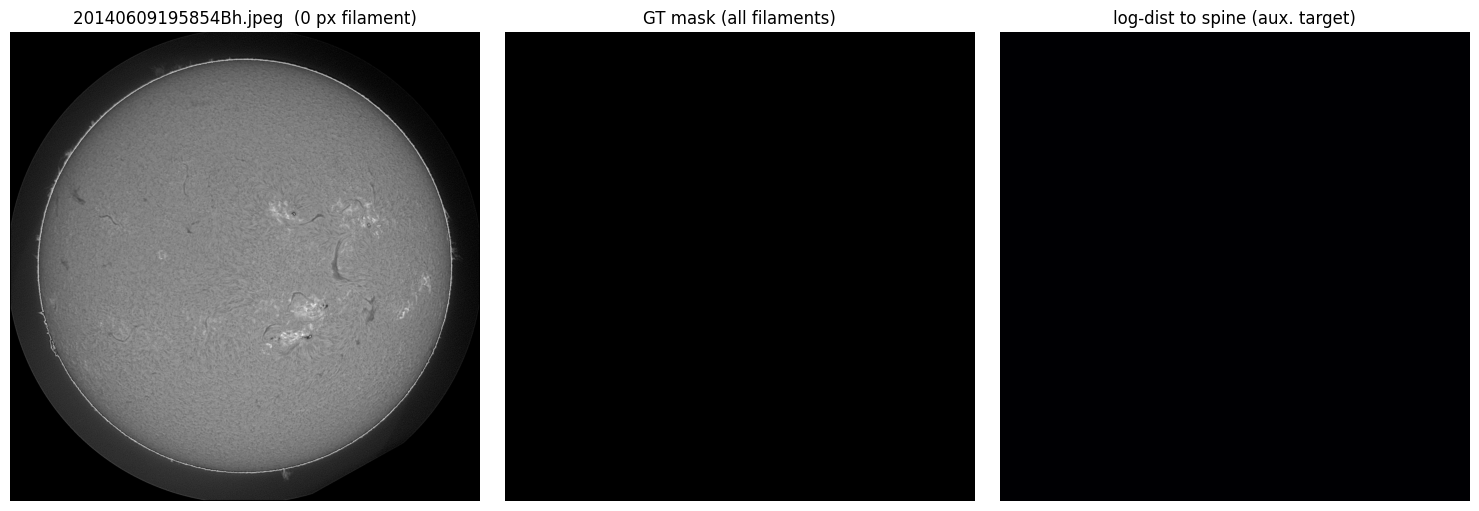

In [ ]:
coco = COCO(CFG.train_json)
img_id = ids[0]
info = coco.loadImgs([img_id])[0]
img = np.asarray(__import__("PIL.Image", fromlist=["open"]).open(
    Path(CFG.data_dir) / "train_images" / info["file_name"]), np.float32) / 255.

h, w = info["height"], info["width"]
gt = np.zeros((h, w), bool)
for ann in coco.loadAnns(coco.getAnnIds(imgIds=img_id)):
    gt |= polygon_to_mask(ann, h, w)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img, cmap="gray"); ax[0].set_title(f"{info['file_name']}  ({gt.sum()} px filament)")
ax[1].imshow(gt, cmap="gray");  ax[1].set_title("GT mask (all filaments)")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

## 4. Optional final training

Final training is disabled by default. Set `TRAIN_FINAL_FOLDS = [0, 1, 2, 3, 4]` and run this cell on a Kaggle GPU. Do not use smoke-test checkpoints for the final submission.

In [11]:
# Final training is intentionally explicit: run this on a Kaggle GPU, not on a CPU kernel.
TRAIN_FINAL_FOLDS = []
FINAL_EPOCHS = 60

for fold in TRAIN_FINAL_FOLDS:
    print(f"training final fold {fold}")
    run_solution("train", "--fold", fold, "--epochs", FINAL_EPOCHS)

if not TRAIN_FINAL_FOLDS:
    print("Final training skipped. Set TRAIN_FINAL_FOLDS = [0, 1, 2, 3, 4] on a GPU to train the ensemble.")

Final training skipped. Set TRAIN_FINAL_FOLDS = [0, 1, 2, 3, 4] on a GPU to train the ensemble.


## 5. Local Panoptic Quality of the trained fold

In [ ]:
run_solution("eval", "--fold", FOLD)

## 6. Post-processing tuning (threshold, watershed min-distance, min-area)

The three post-processing knobs move PQ more than most architecture changes.
The grid is evaluated on the held-out fold with the local PQ implementation.

In [ ]:
run_solution("tune", "--fold", FOLD)

## 7. Test inference + submission CSV

Run this section only after final checkpoints exist. The competition requires one CSV for the complete test set with exactly these columns:

- `filament_id`: a unique image identifier with a unique suffix such as `_1`, `_2`.
- `segmentation_rle`: COCO RLE counts for each predicted instance; masks are fixed at 2048 x 2048.

At inference, use only the supplied H-alpha test images. The final submission package must also include the public GitHub repository, pinned `requirements.txt`, this reproducible notebook, and the technical report submitted through the organizer's final-submission process.

In [ ]:
import glob

ckpts = sorted(glob.glob(f"{CFG.work_dir}/fold*.pt"))
final_ckpts = []
for checkpoint in ckpts:
    payload = torch.load(checkpoint, map_location="cpu")
    checkpoint_cfg = payload.get("cfg", {})
    if checkpoint_cfg.get("limit", 0) == 0 and checkpoint_cfg.get("epochs", 0) >= FINAL_EPOCHS:
        final_ckpts.append(checkpoint)

print("final checkpoints:", final_ckpts)
if not final_ckpts:
    raise RuntimeError(
        "No final checkpoints found. The existing 2-epoch smoke checkpoint is not eligible. "
        "Train final folds on a GPU, then rerun this cell."
    )

run_solution("submit", "--ckpts", *final_ckpts)
sub = pd.read_csv(f"{CFG.work_dir}/submission.csv")
assert list(sub.columns) == ["filament_id", "segmentation_rle"]
assert sub["filament_id"].is_unique
print(sub.head())
print(f"{len(sub)} rows")